# Data Retention Enforcer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/retention-enforcer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/retention-enforcer/demo.ipynb)

Score every record against the retention policy for its data_class, then read an explainable action plan - what is past retention, what is approaching expiry, what is within policy. This tool PLANS for human review; it never auto-deletes.

## Contents
1. [Setup](#setup)
2. [Define retention policies](#policies)
3. [Sample records (fixed AS_OF)](#records)
4. [Evaluate -> action plan](#evaluate)
5. [Read the plan](#read)
6. [Chart: records by action](#chart)
7. [Summary](#summary)
8. [Try your own data](#byo)

This notebook is self-contained - the logic below is duplicated from `enforcer.py` so it runs anywhere with no local imports.

<a id="setup"></a>
## 1. Setup

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility: seeded rng + a FIXED baseline for age, never datetime.now().
rng = np.random.default_rng(42)
AS_OF = pd.Timestamp("2026-07-01")
DEFAULT_WARNING_DAYS = 30

V_PAST = "past_retention"
V_APPROACHING = "approaching"
V_WITHIN = "within_policy"
V_NO_POLICY = "no_policy"

print("AS_OF baseline:", AS_OF.date())

AS_OF baseline: 2026-07-01


<a id="policies"></a>
## 2. Define retention policies

One rule per `data_class`: a max age, the action due once past it, a warning window, and the basis (why it exists).

In [2]:
@dataclass
class RetentionPolicy:
    data_class: str
    max_age_days: int
    action: str                 # "delete" | "anonymize" | "review"
    warning_days: int = DEFAULT_WARNING_DAYS
    basis: str = ""

policies: List[RetentionPolicy] = [
    RetentionPolicy("marketing_lead", 365, "delete", 30,
                    "consent-based marketing, 1yr purpose"),
    RetentionPolicy("transaction", 2555, "anonymize", 90,
                    "7yr tax/finance retention, then de-identify"),
    RetentionPolicy("support_ticket", 730, "review", 60,
                    "2yr service history, review before disposal"),
    RetentionPolicy("audit_log", 3650, "review", 90,
                    "10yr compliance evidence, legal review to dispose"),
]
pd.DataFrame([p.__dict__ for p in policies])

,data_class,max_age_days,action,warning_days,basis
0,marketing_lead,365,delete,30,"consent-based marketing, 1yr purpose"
1,transaction,2555,anonymize,90,"7yr tax/finance retention, then de-identify"
2,support_ticket,730,review,60,"2yr service history, review before disposal"
3,audit_log,3650,review,90,"10yr compliance evidence, legal review to dispose"


<a id="records"></a>
## 3. Sample records (fixed AS_OF)

Dates are anchored to `AS_OF` so ages are deterministic - some records are planted past-due (delete / anonymize / review), some approaching, some fine, plus one unknown class.

In [3]:
def d(days_old: int) -> pd.Timestamp:
    return AS_OF - pd.Timedelta(days=days_old)

planted = [
    ("ML-001", "marketing_lead", 500),   # past -> delete
    ("ML-002", "marketing_lead", 400),   # past -> delete
    ("ML-003", "marketing_lead", 350),   # approaching
    ("ML-004", "marketing_lead", 120),   # within
    ("TX-001", "transaction", 2800),     # past -> anonymize
    ("TX-002", "transaction", 2500),     # approaching
    ("TX-003", "transaction", 300),      # within
    ("ST-001", "support_ticket", 900),   # past -> review
    ("ST-002", "support_ticket", 700),   # approaching
    ("ST-003", "support_ticket", 200),   # within
    ("AL-001", "audit_log", 1000),       # within
    ("AL-002", "audit_log", 3600),       # approaching
    ("XX-001", "biometric_scan", 50),    # unknown class -> no_policy
]
records = pd.DataFrame(
    [(rid, dc, d(age)) for rid, dc, age in planted],
    columns=["record_id", "data_class", "created_date"],
)
records

,record_id,data_class,created_date
0,ML-001,marketing_lead,2025-02-16
1,ML-002,marketing_lead,2025-05-27
2,ML-003,marketing_lead,2025-07-16
3,ML-004,marketing_lead,2026-03-03
4,TX-001,transaction,2018-10-31
5,TX-002,transaction,2019-08-27
6,TX-003,transaction,2025-09-04
7,ST-001,support_ticket,2024-01-13
8,ST-002,support_ticket,2024-07-31
9,ST-003,support_ticket,2025-12-13


<a id="evaluate"></a>
## 4. Evaluate -> action plan

Every record is scored against its class policy. Unknown class -> flagged `no_policy` (a governance gap), never a crash. Empty input -> empty plan.

In [4]:
_VERDICT_RANK = {V_PAST: 0, V_APPROACHING: 1, V_NO_POLICY: 2, V_WITHIN: 3}
_ACTION_RANK = {"delete": 0, "anonymize": 1, "review": 2, "none": 3, "": 3}

def evaluate(records_df: pd.DataFrame,
             policies: List[RetentionPolicy],
             as_of: Optional[pd.Timestamp] = None) -> pd.DataFrame:
    cols = ["record_id", "data_class", "created_date", "as_of", "age_days",
            "max_age_days", "policy_action", "verdict", "action_due", "reason"]
    if records_df is None or records_df.empty:
        return pd.DataFrame(columns=cols)
    as_of = AS_OF if as_of is None else pd.Timestamp(as_of)
    pmap: Dict[str, RetentionPolicy] = {p.data_class: p for p in policies}
    created = pd.to_datetime(records_df["created_date"])
    rows = []
    for i, rec in records_df.reset_index(drop=True).iterrows():
        rid, dclass, cdate = rec["record_id"], rec["data_class"], created.iloc[i]
        age_days = int((as_of.normalize() - cdate.normalize()).days)
        policy = pmap.get(dclass)
        if policy is None:
            rows.append({"record_id": rid, "data_class": dclass,
                         "created_date": cdate, "as_of": as_of, "age_days": age_days,
                         "max_age_days": np.nan, "policy_action": "none",
                         "verdict": V_NO_POLICY, "action_due": "define_policy",
                         "reason": f"data_class '{dclass}' has no retention policy - define one"})
            continue
        max_age = policy.max_age_days
        warn_at = max_age - policy.warning_days
        if age_days > max_age:
            verdict, action = V_PAST, policy.action
            reason = (f"age {age_days}d exceeds {max_age}d limit by {age_days - max_age}d "
                      f"({policy.basis}); action due: {action}")
        elif age_days >= warn_at:
            verdict, action = V_APPROACHING, "none"
            reason = (f"age {age_days}d within {policy.warning_days}d of {max_age}d limit "
                      f"({max_age - age_days}d left); prepare to {policy.action}")
        else:
            verdict, action = V_WITHIN, "none"
            reason = f"age {age_days}d within the {max_age}d limit ({max_age - age_days}d left)"
        rows.append({"record_id": rid, "data_class": dclass,
                     "created_date": cdate, "as_of": as_of, "age_days": age_days,
                     "max_age_days": max_age, "policy_action": policy.action,
                     "verdict": verdict, "action_due": action, "reason": reason})
    plan = pd.DataFrame(rows, columns=cols)
    plan["_v"] = plan["verdict"].map(_VERDICT_RANK).fillna(9)
    plan["_a"] = plan["action_due"].map(_ACTION_RANK).fillna(9)
    plan = plan.sort_values(["_v", "_a", "age_days"], ascending=[True, True, False])
    return plan.drop(columns=["_v", "_a"]).reset_index(drop=True)

plan = evaluate(records, policies, as_of=AS_OF)
print("edge case - empty input ->", len(evaluate(pd.DataFrame(), policies)), "rows")
plan[["record_id", "data_class", "age_days", "max_age_days",
      "verdict", "action_due"]]

edge case - empty input -> 0 rows


,record_id,data_class,age_days,max_age_days,verdict,action_due
0,ML-001,marketing_lead,500,365.0,past_retention,delete
1,ML-002,marketing_lead,400,365.0,past_retention,delete
2,TX-001,transaction,2800,2555.0,past_retention,anonymize
3,ST-001,support_ticket,900,730.0,past_retention,review
4,AL-002,audit_log,3600,3650.0,approaching,none
5,TX-002,transaction,2500,2555.0,approaching,none
6,ST-002,support_ticket,700,730.0,approaching,none
7,ML-003,marketing_lead,350,365.0,approaching,none
8,XX-001,biometric_scan,50,NaN,no_policy,define_policy
9,AL-001,audit_log,1000,3650.0,within_policy,none


<a id="read"></a>
## 5. Read the plan

Sorted by urgency. The `reason` column is the auditable explanation for each verdict.

In [5]:
with pd.option_context("display.max_colwidth", 90):
    display(plan[["record_id", "data_class", "age_days", "verdict",
                  "action_due", "reason"]])

,record_id,data_class,age_days,verdict,action_due,reason
0,ML-001,marketing_lead,500,past_retention,delete,"age 500d exceeds 365d limit by 135d (consent-based marketing, 1yr purpose); action due..."
1,ML-002,marketing_lead,400,past_retention,delete,"age 400d exceeds 365d limit by 35d (consent-based marketing, 1yr purpose); action due:..."
2,TX-001,transaction,2800,past_retention,anonymize,"age 2800d exceeds 2555d limit by 245d (7yr tax/finance retention, then de-identify); a..."
3,ST-001,support_ticket,900,past_retention,review,"age 900d exceeds 730d limit by 170d (2yr service history, review before disposal); act..."
4,AL-002,audit_log,3600,approaching,none,age 3600d within 90d of 3650d limit (50d left); prepare to review
5,TX-002,transaction,2500,approaching,none,age 2500d within 90d of 2555d limit (55d left); prepare to anonymize
6,ST-002,support_ticket,700,approaching,none,age 700d within 60d of 730d limit (30d left); prepare to review
7,ML-003,marketing_lead,350,approaching,none,age 350d within 30d of 365d limit (15d left); prepare to delete
8,XX-001,biometric_scan,50,no_policy,define_policy,data_class 'biometric_scan' has no retention policy - define one
9,AL-001,audit_log,1000,within_policy,none,age 1000d within the 3650d limit (2650d left)


<a id="chart"></a>
## 6. Chart: records by action

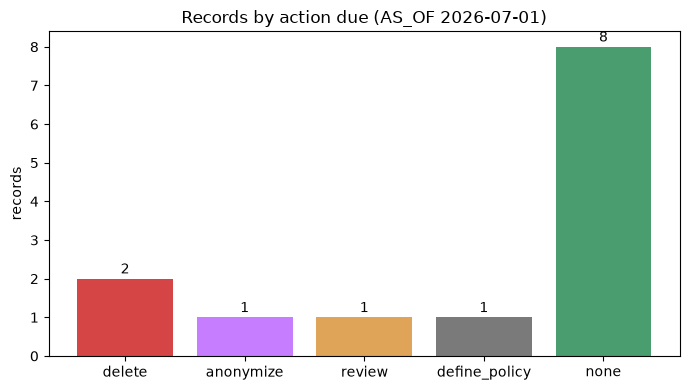

,action_due,records,approx_gb
0,delete,2,0.0
1,anonymize,1,0.0
2,review,1,0.0
3,define_policy,1,0.0
4,none,8,0.0


In [6]:
def summarize(plan: pd.DataFrame) -> pd.DataFrame:
    cols = ["action_due", "records", "approx_gb"]
    if plan is None or plan.empty:
        return pd.DataFrame(columns=cols)
    grp = plan.groupby("action_due").size().rename("records").reset_index()
    grp["approx_gb"] = (grp["records"] * 5.0 / (1024 * 1024)).round(4)
    order = {"delete": 0, "anonymize": 1, "review": 2, "define_policy": 3, "none": 4}
    grp["_o"] = grp["action_due"].map(order).fillna(9)
    return grp.sort_values("_o").drop(columns=["_o"])[cols].reset_index(drop=True)

roll = summarize(plan)

ACTION_COLOR = {"delete": "#d64545", "anonymize": "#c77dff", "review": "#e0a458",
                "define_policy": "#7a7a7a", "none": "#4a9d6f"}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(roll["action_due"], roll["records"],
       color=[ACTION_COLOR.get(a, "#888") for a in roll["action_due"]])
ax.set_ylabel("records")
ax.set_title("Records by action due (AS_OF 2026-07-01)")
for i, v in enumerate(roll["records"]):
    ax.text(i, v + 0.05, str(v), ha="center", va="bottom")
fig.tight_layout()
fig.savefig("records_by_action.png", dpi=150)
plt.show()
roll

<a id="summary"></a>
## 7. Summary

The engine turned a pile of records into a defensible schedule: **2 marketing leads past their 1-year purpose** (action: delete), **1 transaction** past its 7-year window (anonymize), **1 support ticket** past its 2-year window (review), and **4 records approaching expiry** that need a heads-up before they cross the line. One record (`biometric_scan`) has **no policy at all** - itself an audit finding, surfaced instead of silently ignored.

Every verdict carries its `reason`, so the plan is auditable. Nothing was deleted - this is a prioritized review queue. Legal owns the policy; confirm legal holds and business need before any disposal.

<a id="byo"></a>
## 8. Try your own data

Uncomment and point at a CSV with `record_id`, `created_date`, and `data_class` columns.

In [7]:
# my_records = pd.read_csv("my_records.csv")
# my_plan = evaluate(my_records, policies, as_of=AS_OF)
# my_plan.head(20)

---
Day 96 of the FDE portfolio - [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)